In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
import yfinance as yf
from hmmlearn import hmm
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler 
import cvxpy as cp
from fredapi import Fred
from datetime import datetime,timedelta

In [104]:
tickers = ["^NSEI","GOLD","^INDIAVIX","INR=X","^NSEBANK","BZ=F","^GSPC","^IXIC"]
start_date = datetime.today()-timedelta(days=365*5)
end_date = start_date + timedelta(days=5*365-2)
raw = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)

In [105]:
raw["Close"] = raw["Close"].ffill()
raw

Price           Close                                               \
Ticker           BZ=F       GOLD      INR=X        ^GSPC ^INDIAVIX   
Date                                                                 
2021-07-13  76.489998  18.819162  74.541702  4369.209961     12.62   
2021-07-14  74.760002  18.392771  74.659103  4374.299805     12.59   
2021-07-15  73.470001  18.467287  74.469101  4360.029785     12.27   
2021-07-16  73.589996  18.289274  74.537003  4327.160156     11.71   
2021-07-19  68.620003  18.173367  74.631798  4258.490234     12.68   
...               ...        ...        ...          ...       ...   
2026-07-06  71.989998  44.049999  95.214798  7537.430176     11.82   
2026-07-07  74.160004  43.349998  95.603500  7503.850098     11.65   
2026-07-08  78.019997  41.279999  95.593399  7482.709961     14.68   
2026-07-09  76.300003  41.709999  95.861801  7543.640137     13.36   
2026-07-10  76.010002  41.709999  95.390198  7543.640137     13.36   

Price                                                      High             \
Ticker             ^IXIC      ^NSEBANK         ^NSEI       BZ=F       GOLD   
Date                                                                         
2021-07-13  14677.650391  35672.984375  15812.349609  76.610001  19.601569   
2021-07-14  14644.950195  35667.835938  15853.950195  76.709999  19.251763   
2021-07-15  14543.129883  35907.230469  15924.200195  74.639999  18.773625   
2021-07-16  14427.240234  35751.386719  15923.400391  74.070000  18.943349   
2021-07-19  14274.980469  35078.792969  15752.400391  73.290001  18.214763   
...                  ...           ...           ...        ...        ...   
2026-07-06  26121.160156  58291.500000  24430.349609  72.589996  45.000000   
2026-07-07  25818.689453  58200.699219  24398.699219  76.349998  44.470001   
2026-07-08  25870.650391  56742.601562  23882.050781  80.570000  43.110001   
2026-07-09  26206.890625  57252.449219  23962.800781  79.379997  42.189999   
2026-07-10  26206.890625  57252.449219  23962.800781  77.559998        NaN   

Price       ...          Open                 Volume                  \
Ticker      ...      ^NSEBANK         ^NSEI     BZ=F      GOLD INR=X   
Date        ...                                                        
2021-07-13  ...  35479.638963  15794.000000  32219.0  138800.0   0.0   
2021-07-14  ...  35585.438457  15808.700195  49772.0  100800.0   0.0   
2021-07-15  ...  35757.032998  15872.150391  41748.0  150600.0   0.0   
2021-07-16  ...  35977.532537  15958.349609  33536.0  110000.0   0.0   
2021-07-19  ...  35070.093851  15754.500000  58659.0  145600.0   0.0   
...         ...           ...           ...      ...       ...   ...   
2026-07-06  ...  57983.898438  24306.849609  46238.0  428400.0   0.0   
2026-07-07  ...  58567.851562  24464.449219  58154.0  275700.0   0.0   
2026-07-08  ...  57918.250000  24259.550781  96042.0  463600.0   0.0   
2026-07-09  ...  56871.000000  23928.949219  47817.0  307200.0   0.0   
2026-07-10  ...           NaN           NaN  47817.0       NaN   0.0   

Price                                                                 
Ticker             ^GSPC ^INDIAVIX         ^IXIC  ^NSEBANK     ^NSEI  
Date                                                                  
2021-07-13  3.695430e+09       0.0  4.583460e+09       0.0  246700.0  
2021-07-14  4.006370e+09       0.0  4.496220e+09       0.0       0.0  
2021-07-15  3.905230e+09       0.0  4.512550e+09       0.0  284900.0  
2021-07-16  3.985700e+09       0.0  4.069530e+09       0.0  276300.0  
2021-07-19  5.157660e+09       0.0  4.537130e+09       0.0  242100.0  
...                  ...       ...           ...       ...       ...  
2026-07-06  4.971110e+09       0.0  7.827050e+09  284400.0  329400.0  
2026-07-07  5.049590e+09       0.0  8.244680e+09  261900.0  412600.0  
2026-07-08  5.102020e+09       0.0  7.935740e+09  304900.0  420500.0  
2026-07-09  4.442950e+09       0.0  7.312220e+09  231600.0  38480

In [106]:
logr = np.log(raw["Close"]).diff()
logr.columns = pd.MultiIndex.from_product([["logr"], logr.columns])
raw = pd.concat([raw, logr], axis=1)
pct=raw["Close"].pct_change()
pct.columns=pd.MultiIndex.from_product([["pct"],pct.columns])
raw=pd.concat([raw,pct],axis=1)

for window in [5, 21, 63]:
    mom = raw["Close"].pct_change(window, fill_method=None)
    mom.columns = pd.MultiIndex.from_product([[f"mom{window}"], mom.columns])
    raw = pd.concat([raw, mom], axis=1)


for window in [5, 21, 63]:
    vol = raw["pct"].rolling(window).std() * np.sqrt(252)
    vol.columns = pd.MultiIndex.from_product([[f"vol{window}"], vol.columns])
    raw = pd.concat([raw, vol], axis=1)
    
rolling_max = raw["Close"].rolling(63).max()
drawdown = raw["Close"] / rolling_max - 1
drawdown.columns = pd.MultiIndex.from_product([["drawdown63"], drawdown.columns])
raw = pd.concat([raw, drawdown], axis=1)

vix_change = raw["Close"]["^INDIAVIX"].pct_change(5, fill_method=None)
raw[("vix_change5", "^INDIAVIX")] = vix_change

nifty_gold_corr = (raw["pct"]["^NSEI"].rolling(21).corr(raw["pct"]["GOLD"]))

raw[("corr21", "NIFTY_GOLD")] = nifty_gold_corr

nifty_bank_corr = (raw["pct"]["^NSEI"].rolling(21).corr(raw["pct"]["^NSEBANK"]))

raw[("corr21", "NIFTY_BANK")] = nifty_bank_corr

In [107]:
features = pd.DataFrame({
    "nifty_mom5": raw["mom5"]["^NSEI"],
    "nifty_mom21": raw["mom21"]["^NSEI"],
    "nifty_mom63": raw["mom63"]["^NSEI"],
    "nifty_vol21": raw["vol21"]["^NSEI"],
    "nifty_vol63": raw["vol63"]["^NSEI"],
    "nifty_drawdown": raw["drawdown63"]["^NSEI"],
    "vix": raw["Close"]["^INDIAVIX"],
    "vix_change5": raw["vix_change5"]["^INDIAVIX"],
    "gold_mom21": raw["mom21"]["GOLD"],
    "usdinr_mom21": raw["mom21"]["INR=X"],
    "bank_vol21": raw["vol21"]["^NSEBANK"],
    "crude_mom21": raw["mom21"]["BZ=F"],
    "nifty_gold_corr": raw["corr21"]["NIFTY_GOLD"],
    "nifty_bank_corr": raw["corr21"]["NIFTY_BANK"],
    "IXIC":raw["Close"]["^IXIC"]
})
features=features.ffill()
features=features.dropna()

In [108]:
features

,nifty_mom5,nifty_mom21,nifty_mom63,nifty_vol21,nifty_vol63,nifty_drawdown,vix,vix_change5,gold_mom21,usdinr_mom21,bank_vol21,crude_mom21,nifty_gold_corr,nifty_bank_corr,IXIC
Date,,,,,,,,,,,,,,,
2021-10-08,0.020713,0.030280,0.131723,0.109619,0.096354,0.000000,15.65,-0.090645,0.371178,0.014108,0.153025,0.153114,0.175516,0.803276,14579.540039
2021-10-11,0.014397,0.033202,0.131954,0.109589,0.096361,0.000000,16.09,-0.038829,0.180525,0.024039,0.158679,0.147148,0.257764,0.784406,14486.200195
2021-10-12,0.009519,0.036683,0.129849,0.109286,0.096241,0.000000,15.85,-0.033537,0.154548,0.025547,0.156543,0.134812,0.239146,0.784931,14465.919922
2021-10-13,0.029228,0.044980,0.140570,0.112474,0.097301,0.000000,16.10,-0.070975,0.214936,0.026422,0.156485,0.130163,0.283586,0.765213,14571.639648
2021-10-14,0.030815,0.046754,0.164175,0.113754,0.094900,0.000000,15.77,-0.024134,0.191677,0.022478,0.165208,0.113173,0.253797,0.780327,14823.429688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-06,0.020216,0.045520,0.018044,0.114058,0.122937,-0.005951,11.82,-0.131521,0.111812,-0.006008,0.157121,-0.226662,-0.053794,0.857573,26121.160156
2026-07-07,0.022331,0.055170,0.026229,0.105432,0.121438,-0.007239,11.65,-0.143382,0.071429,0.006879,0.152892,-0.213156,0.037740,0.854157,25818.689453
2026-07-08,-0.005157,0.027534,-0.007008,0.133147,0.126775,-0.028261,14.68,0.108761,-0.014562,-0.000992,0.169203,-0.146856,0.283108,0.934178,25870.650391


In [109]:
X=features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model=hmm.GaussianHMM(n_components=3,covariance_type='diag',n_iter=1000,random_state=42)
model.fit(X_scaled)
hidden_states = model.predict(X_scaled)  
features["state"] = hidden_states

print("Transition matrix:\n", np.round(model.transmat_, 3))
print("\nMean feature values per state :\n",np.round(model.means_, 4))
print("\nState counts:\n", features["state"].value_counts())

Transition matrix:
 [[0.972 0.028 0.   ]
 [0.015 0.969 0.016]
 [0.    0.019 0.981]]

Mean feature values per state :
 [[-0.0858 -0.3963 -0.7109  1.4071  1.2231 -0.9065  1.2309  0.0259 -0.4685
   0.4818  1.3546  0.3865 -0.0255  0.7157 -0.0952]
 [-0.0318 -0.0053  0.0583 -0.0701 -0.0798 -0.0303  0.033   0.0571 -0.0592
  -0.2082 -0.0204 -0.1522  0.1245 -0.097  -0.0657]
 [ 0.0952  0.2702  0.4034 -0.8526 -0.7185  0.6398 -0.8589 -0.0857  0.3828
  -0.0711 -0.8773 -0.0748 -0.1322 -0.3601  0.1421]]

State counts:
 state
1    524
2    429
0    287
Name: count, dtype: int64


In [110]:
feature_names = features.drop(columns=["state", "regime"],errors="ignore").columns
state_means = pd.DataFrame(model.means_,columns=feature_names)

state_counts = features["state"].value_counts()

transition_matrix = model.transmat_

crisis_state = (state_means["nifty_vol21"]+ state_means["vix"]).idxmax()

remaining_states = [i for i in range(model.n_components)if i != crisis_state]

bull_state = state_means.loc[remaining_states,"nifty_mom21"].idxmax()

bear_state = state_means.loc[remaining_states,"nifty_mom21"].idxmin()

regime_map = {bull_state: "Bull",bear_state: "Bear",crisis_state: "Crisis"}

features["regime"] = features["state"].map(regime_map)

feature_names = features.drop(columns=["state", "regime"]).columns
state_means = pd.DataFrame(model.means_,columns=feature_names,index=["State 0", "State 1", "State 2"])

print(state_means.T)

                  State 0   State 1   State 2
nifty_mom5      -0.085810 -0.031753  0.095187
nifty_mom21     -0.396317 -0.005347  0.270221
nifty_mom63     -0.710867  0.058255  0.403356
nifty_vol21      1.407066 -0.070125 -0.852555
nifty_vol63      1.223070 -0.079807 -0.718471
nifty_drawdown  -0.906481 -0.030322  0.639755
vix              1.230935  0.032987 -0.858925
vix_change5      0.025894  0.057130 -0.085725
gold_mom21      -0.468542 -0.059165  0.382816
usdinr_mom21     0.481828 -0.208218 -0.071118
bank_vol21       1.354618 -0.020355 -0.877308
crude_mom21      0.386521 -0.152204 -0.074826
nifty_gold_corr -0.025533  0.124458 -0.132206
nifty_bank_corr  0.715656 -0.096972 -0.360129
IXIC            -0.095242 -0.065667  0.142120


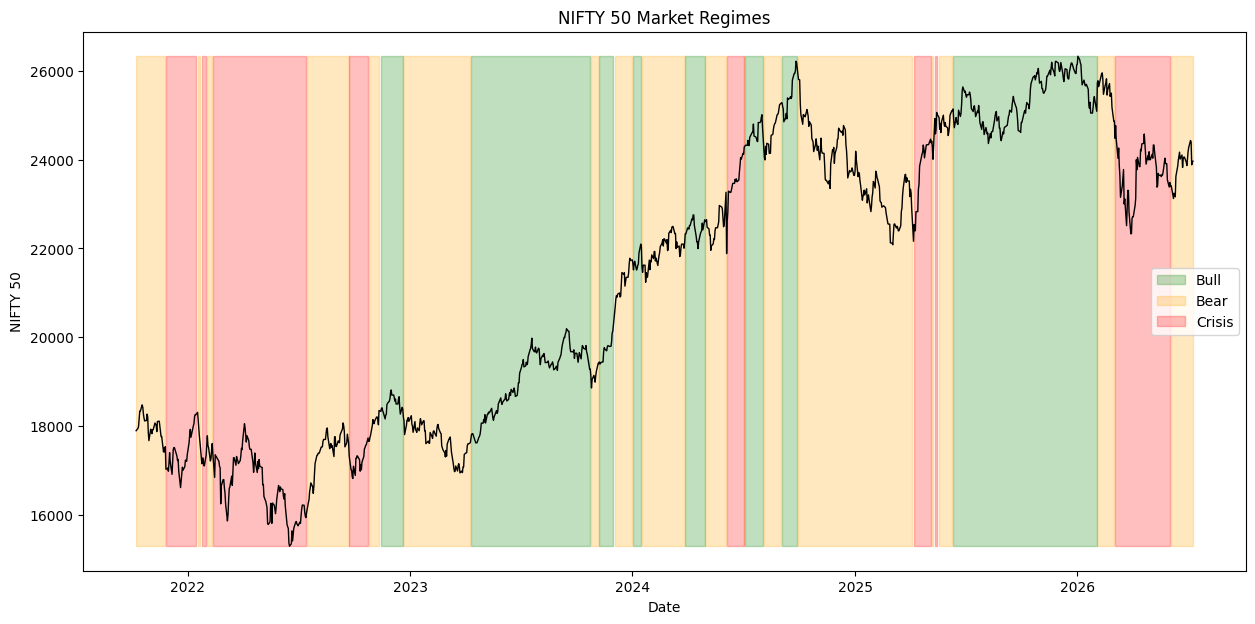

In [111]:
plot_data = raw["Close"]["^NSEI"].reindex(features.index)

colors = {"Bull": "green","Bear": "orange","Crisis": "red"}

plt.figure(figsize=(15, 7))

plt.plot(plot_data.index,plot_data,color="black",linewidth=1)

for regime, color in colors.items():
    mask = features["regime"] == regime
    plt.fill_between(plot_data.index,plot_data.min(),plot_data.max(),where=mask,color=color,alpha=0.25,label=regime)

plt.title("NIFTY 50 Market Regimes")
plt.xlabel("Date")
plt.ylabel("NIFTY 50")
plt.legend()
plt.show()

In [112]:
def walkforward(features,n_splits=5):
    X = features.drop(columns=["state", "regime"], errors="ignore")

    n = len(X)
    block_size = n // n_splits

    results = []

    for i in range(1, n_splits):
        train_end = i * block_size
        test_end = (i + 1) * block_size if i < n_splits - 1 else n

        X_train = X.iloc[:train_end]
        X_test = X.iloc[train_end:test_end]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = hmm.GaussianHMM(n_components=3,covariance_type="diag",n_iter=1000,random_state=42)

        model.fit(X_train_scaled)

        state_means = pd.DataFrame(model.means_,columns=X.columns)

        crisis_state = (state_means["nifty_vol21"] + state_means["vix"]- state_means["nifty_mom21"]).idxmax()

        remaining_states = [state for state in range(model.n_components)if state != crisis_state ]

        bull_state = state_means.loc[remaining_states, "nifty_mom21"].idxmax()

        bear_state = state_means.loc[remaining_states, "nifty_mom21"].idxmin()

        regime_map = {bull_state: "Bull",bear_state: "Bear",crisis_state: "Crisis"}

        hidden_states = []

        for t in range(len(X_test_scaled)):
            X_seen = X_test_scaled[:t + 1]

            state = model.predict(X_seen)[-1]

            hidden_states.append(state)

        fold_result = pd.DataFrame(
            {
                "state": hidden_states,
                "regime": [
                    regime_map[state]
                    for state in hidden_states
                ]
            },
            index=X_test.index
        )

        results.append(fold_result)

        print(f"Fold {i}: "f"Train = {len(X_train)}, "f"Test = {len(X_test)}")

    return pd.concat(results)

In [113]:
walkforward_results = walkforward(features)

walkforward_results

Fold 1: Train = 248, Test = 248
Fold 2: Train = 496, Test = 248
Fold 3: Train = 744, Test = 248
Fold 4: Train = 992, Test = 248


,state,regime
Date,,
2022-09-21,0,Bull
2022-09-22,2,Bear
2022-09-23,2,Bear
2022-09-26,2,Bear
2022-09-27,2,Bear
...,...,...
2026-07-06,0,Bull
2026-07-07,1,Bear
2026-07-08,0,Bull


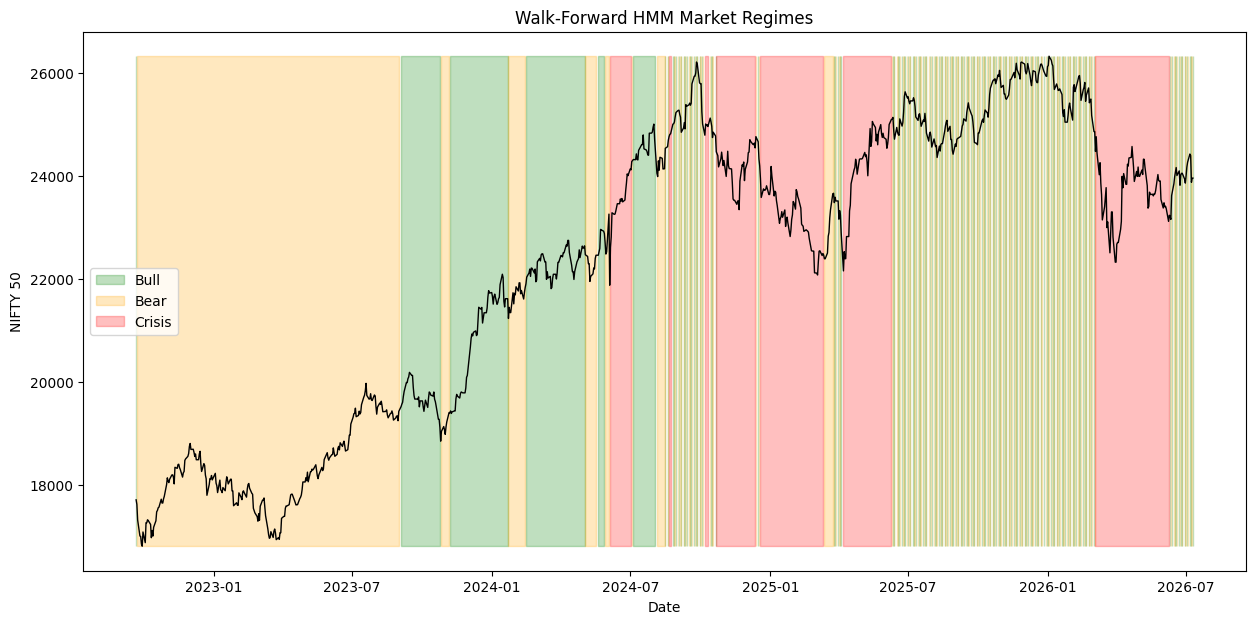

In [114]:
plot_data = raw["Close"]["^NSEI"].reindex(walkforward_results.index)

colors = {"Bull": "green","Bear": "orange","Crisis": "red"}

plt.figure(figsize=(15, 7))

plt.plot(plot_data.index,plot_data,color="black",linewidth=1)

for regime, color in colors.items():
    mask = walkforward_results["regime"] == regime

    plt.fill_between(
        plot_data.index,
        plot_data.min(),
        plot_data.max(),
        where=mask,
        color=color,
        alpha=0.25,
        label=regime
    )

plt.title("Walk-Forward HMM Market Regimes")
plt.xlabel("Date")
plt.ylabel("NIFTY 50")
plt.legend()
plt.show()

In [115]:
def sharpe_ratio(port_return:np.ndarray,risk_free_return:np.ndarray):
    s = port_return - risk_free_return
    return np.sum(s)/np.std(s)

In [116]:
risk_free_rate = 0.02
api_key = '6161efead72b475798ea17b18ca85cd7'
fred = Fred(api_key=api_key)
ten_year_treasury_rate = fred.get_series_latest_release('GS10')/100
risk_free_rate = ten_year_treasury_rate.iloc[-1]
risk_free_rate=0.03

In [117]:
#max sharpe
def bull_portfolio(mu, Sigma, risk_free_rate, u=0.20):
    n = len(mu)

    y = cp.Variable(n)
    k = cp.Variable(nonneg=True)

    diff = mu - risk_free_rate

    obj = cp.Minimize(cp.quad_form(y,Sigma))
    constraints = [diff @ y == 1, cp.sum(y) == k, y >= 0, y <= u*k]
    
    problem = cp.Problem(obj,constraints)
    problem.solve()
    # print(problem.status)
    if problem.status in ["infeasible", "unbounded"]:
        return None
    
    w = y.value / k.value

    return w

# markowitz portfolio with cash allocation
def bear_portfolio(mu , Sigma,risk_free_rate,lam=5.0,u = 0.10,f=1):
    n = len(mu)

    x = cp.Variable(n)
    if(f):
        c = 1 - cp.sum(x)
        constraints = [cp.sum(x)<=1,x>=0,x<=u]
        portfolio_return = mu @ x - risk_free_rate*c
    else:
        c = 0
        constraints = [cp.sum(x)==1,x>=0,x<=u]
        portfolio_return = (mu @ x)


    risk = cp.quad_form(x,Sigma)


    objective = cp.Maximize(portfolio_return - lam*risk)
    problem = cp.Problem(objective,constraints)

    problem.solve()
    # print(problem.status)

    if problem.status in ["infeasible", "unbounded"]:
        return None,None
    
    w = x.value
    if(f): cash_w = 1 - np.sum(w)
    else: cash_w = 0
    return w,cash_w

def crisis_portfolio(Sigma,u=0.05):
    n = Sigma.shape[0]

    x = cp.Variable(n)

    objective = cp.Minimize(cp.quad_form(x, Sigma))

    constraints = [cp.sum(x) <= 1,x >= 0,x <= u]

    problem = cp.Problem(objective, constraints)
    problem.solve()
    # print(problem.status)
    if problem.status in ["infeasible", "unbounded"]:
        return None,None

    w = x.value
    cash_w = 1 - np.sum(w)

    return w, cash_w

In [118]:
tickers_trade = ["HDFCBANK.NS","ICICIBANK.NS","SBIN.NS","AXISBANK.NS","EBBETF0433.NS"]

In [119]:
adj_close_df = pd.DataFrame()
for t in tickers_trade:
    data = yf.download(t,start = start_date , end = end_date)
    adj_close_df[t]=data['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [120]:
def update_mu_sigma(mu, M2, new_return, n):
    delta = new_return - mu
    mu = mu + delta / n
    delta2 = new_return - mu

    M2 = M2 + np.outer(delta, delta2)

    Sigma = M2 / (n - 1) if n > 1 else np.zeros_like(M2)
    return mu, Sigma, M2

In [121]:
logr_trade = np.log(adj_close_df).diff().dropna()

In [122]:
portfolio_returns = []
weights_history = []

# Align returns with regime predictions once
aligned_returns = logr_trade.loc[walkforward_results.index]
walk = len(features)//5

for t in range(walk, len(walkforward_results)):

    # Current predicted regime
    regime = walkforward_results.iloc[t]["regime"]

    # Historical data available up to yesterday
    hist = aligned_returns.iloc[:t]

    # Historical observations belonging to the same regime
    regime_hist = hist[
        walkforward_results.iloc[:t]["regime"] == regime
    ]

    mu = regime_hist.mean().values * 252
    Sigma = regime_hist.cov().values * 252

    if regime == "Bull":
        w = bull_portfolio(mu, Sigma, risk_free_rate)
        cash = 0.0

    elif regime == "Bear":
        w, cash = bear_portfolio(mu, Sigma, risk_free_rate)

    else:
        w, cash = crisis_portfolio(Sigma)

    weights_history.append(w)

    # Realized return on the next day
    r_next = aligned_returns.iloc[t].values

    portfolio_returns.append(
        np.dot(w, r_next) + cash * risk_free_rate
    )

KeyError: "[Timestamp('2022-09-21 00:00:00'), Timestamp('2022-09-22 00:00:00'), Timestamp('2022-09-23 00:00:00'), Timestamp('2022-09-26 00:00:00'), Timestamp('2022-09-27 00:00:00'), Timestamp('2022-09-28 00:00:00'), Timestamp('2022-09-29 00:00:00'), Timestamp('2022-09-30 00:00:00'), Timestamp('2022-10-03 00:00:00'), Timestamp('2022-10-04 00:00:00'), Timestamp('2022-10-05 00:00:00'), Timestamp('2022-10-06 00:00:00'), Timestamp('2022-10-07 00:00:00'), Timestamp('2022-10-10 00:00:00'), Timestamp('2022-10-11 00:00:00'), Timestamp('2022-10-12 00:00:00'), Timestamp('2022-10-13 00:00:00'), Timestamp('2022-10-14 00:00:00'), Timestamp('2022-10-17 00:00:00'), Timestamp('2022-10-18 00:00:00'), Timestamp('2022-10-19 00:00:00'), Timestamp('2022-10-20 00:00:00'), Timestamp('2022-10-21 00:00:00'), Timestamp('2022-10-24 00:00:00'), Timestamp('2022-10-25 00:00:00'), Timestamp('2022-10-26 00:00:00'), Timestamp('2022-10-27 00:00:00'), Timestamp('2022-10-28 00:00:00'), Timestamp('2022-10-31 00:00:00'), Ti

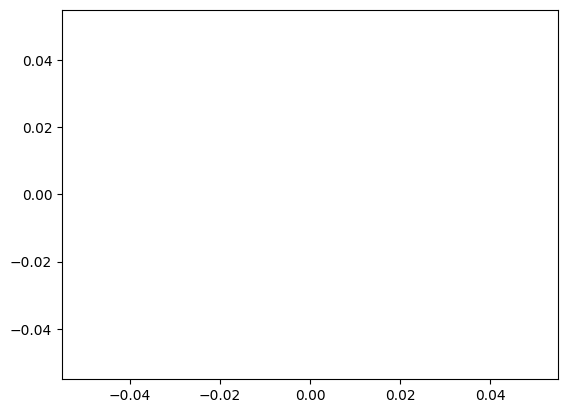

In [ ]:
plt.plot(portfolio_returns)

In [123]:
print(logr_trade.index.dtype)
print(walkforward_results.index.dtype)

print(logr_trade.index[:5])
print(walkforward_results.index[:5])

datetime64[s]
datetime64[s]
DatetimeIndex(['2025-03-04', '2025-03-05', '2025-03-06', '2025-03-07',
               '2025-03-10'],
              dtype='datetime64[s]', name='Date', freq=None)
DatetimeIndex(['2022-09-21', '2022-09-22', '2022-09-23', '2022-09-26',
               '2022-09-27'],
              dtype='datetime64[s]', name='Date', freq=None)


In [124]:
missing = walkforward_results.index.difference(logr_trade.index)
print(len(missing))
print(missing[:10])

663
DatetimeIndex(['2022-09-21', '2022-09-22', '2022-09-23', '2022-09-26',
               '2022-09-27', '2022-09-28', '2022-09-29', '2022-09-30',
               '2022-10-03', '2022-10-04'],
              dtype='datetime64[s]', name='Date', freq=None)
